In [1]:
import requests

url='https://storage.googleapis.com/theresult42/aeb/aebc8fbf-b897-4f7f-a4fc-95e936e37940/output.zip?GoogleAccessId=cloud-api%40gentle-impulse-371419.iam.gserviceaccount.com&Expires=1757112103&Signature=pCnWo2fXhBGvGIyvw65DR1kqu7aX14VoFdn1lp7%2BzaZAGqLBS1FaTWypa7eStaKosGjpatpjkK%2FO%2BaDEhOOgXFd8uuZyFLjEk2iMo9L%2F%2FLrzag2kPFlC8t1x5aCZ%2BXzQx9HWqh5wJ3s2s%2Fdqqw4cdto3rPioHuHUYVBKr%2BMVbi9HNNhGHAZMw5bLwIRwffKcHo4PQhVkweat%2B1jcpwWtOpmbv%2BAlAJUW58CPOUmvUW1pQDpva95thGwNZDaPYQAz%2Boye2Sgv6fJt3BjUV9mgebOj12CbI6I8zHe0OnIl9g38aXgyuNKBHCMJuGH3h7X4u6XFQu2oBgne25By8sXlYg%3D%3D&response-content-disposition=attachment%3B%20filename%3D%22output.zip%22'

response = requests.get(url)

with open("output.zip", "wb") as f:
    f.write(response.content)

print("Download complete.")

Download complete.


In [2]:
import zipfile

with zipfile.ZipFile("output.zip", "r") as zip_ref:
    zip_ref.extractall("unzipped_output")

print("Unzipped contents to 'unzipped_output/'")


Unzipped contents to 'unzipped_output/'


In [6]:
import os
import shutil
from IPython.display import display, clear_output
from ipywidgets import Button, HBox, VBox, Image, Output
from PIL import Image as PILImage
import io

# Paths
image_dir = '/content/unzipped_output/Output/2025-08-21-19-30-50/train/images'
label_dir = '/content/unzipped_output/Output/2025-08-21-19-30-50/train/labels'
output_dir = '/content/'
accepted_images_dir = os.path.join(output_dir, 'images')
accepted_labels_dir = os.path.join(output_dir, 'labels')

# Refresh output directories (remove if exist, then recreate)
for d in [accepted_images_dir, accepted_labels_dir]:
    if os.path.exists(d):
        shutil.rmtree(d)   # delete entire directory
    os.makedirs(d)         # recreate it empty

# List images
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
index = 0

out = Output()

def show_image(idx):
    out.clear_output()
    if idx < len(image_files):
        image_path = os.path.join(image_dir, image_files[idx])
        # Open image with PIL
        img = PILImage.open(image_path)
        # Resize image for faster display (e.g., 400x400) using Lanczos filter
        img_resized = img.resize((400, 400), PILImage.LANCZOS)
        # Convert PIL image to bytes for ipywidgets Image display
        with io.BytesIO() as output:
            img_resized.save(output, format="PNG")
            img_data = output.getvalue()
        img_widget = Image(value=img_data, format='png', width=400, height=400)
        with out:
            clear_output(wait=True)
            display(img_widget)
    else:
        with out:
            clear_output(wait=True)
            print("No more images!")

def on_accept_clicked(b):
    global index
    # Move image
    image_src = os.path.join(image_dir, image_files[index])
    image_dst = os.path.join(accepted_images_dir, image_files[index])
    shutil.move(image_src, image_dst)

    # Move corresponding label
    label_file = os.path.splitext(image_files[index])[0] + '.txt'
    label_src = os.path.join(label_dir, label_file)
    label_dst = os.path.join(accepted_labels_dir, label_file)
    if os.path.exists(label_src):
        shutil.move(label_src, label_dst)

    index += 1
    show_image(index)

def on_reject_clicked(b):
    global index
    index += 1
    show_image(index)

accept_button = Button(description="Accept", button_style='success')
reject_button = Button(description="Reject", button_style='danger')

accept_button.on_click(on_accept_clicked)
reject_button.on_click(on_reject_clicked)

buttons = HBox([accept_button, reject_button])

display(VBox([out, buttons]))

# Show first image initially
show_image(index)


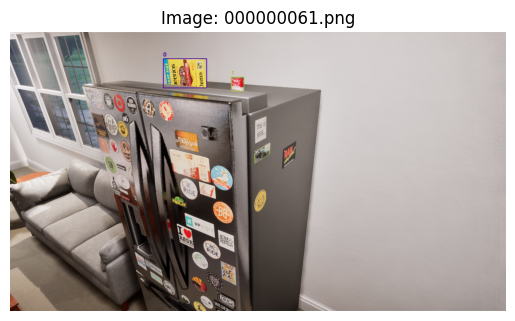

In [7]:
import cv2
import os
import matplotlib.pyplot as plt
import re
import random

def extract_number(filename):
    match = re.search(r'(\d{4})', filename)
    if match:
        return int(match.group(1))
    else:
        return -1

# Generate a color map for class IDs dynamically
def generate_color_map(num_classes):
    random.seed(42)
    color_map = {}
    for i in range(num_classes):
        color_map[str(i)] = tuple(random.choices(range(256), k=3))
    return color_map

def draw_yolo_boxes(image, label_path, color_map):
    height, width = image.shape[:2]
    if not os.path.exists(label_path):
        return image
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id, x_center, y_center, w, h = parts
            x_center, y_center, w, h = float(x_center), float(y_center), float(w), float(h)
            x1 = int((x_center - w / 2) * width)
            y1 = int((y_center - h / 2) * height)
            x2 = int((x_center + w / 2) * width)
            y2 = int((y_center + h / 2) * height)

            color = color_map.get(class_id, (0, 255, 0))  # default green if not found
            color = tuple(int(c) for c in color)
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
            cv2.putText(image, class_id, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, color, 2)
    return image

def show_images_from_folder_with_labels(image_folder, label_folder, display_time=1, descending=False):
    files = os.listdir(image_folder)
    image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.tiff')
    images = [f for f in files if f.lower().endswith(image_extensions)]
    if not images:
        print("No images found in the given folder.")
        return
    images.sort(key=extract_number, reverse=descending)

    # Determine the number of classes by scanning label files (optional optimization)
    class_ids = set()
    for label_file in os.listdir(label_folder):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_folder, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 1:
                        class_ids.add(parts[0])
    color_map = generate_color_map(len(class_ids))

    plt.ion()
    for image_name in images:
        image_path = os.path.join(image_folder, image_name)
        label_path = os.path.join(label_folder, os.path.splitext(image_name)[0] + '.txt')
        image = cv2.imread(image_path)
        if image is None:
            print(f"Could not open {image_name}")
            continue
        image = draw_yolo_boxes(image, label_path, color_map)

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.clf()
        plt.imshow(image_rgb)
        plt.title(f"Image: {image_name}")
        plt.axis('off')
        plt.draw()
        plt.pause(display_time)
    plt.ioff()
    plt.show()

image_folder = "/content/images"
label_folder = "/content/labels"
show_images_from_folder_with_labels(image_folder, label_folder, display_time=0.1, descending=False)
